In [1]:
from brainlit.preprocessing import removeSmallCCs
from brainlit.BrainLine.analyze_results import SomaDistribution
from brainlit.BrainLine.util import (
    json_to_points,
    download_subvolumes,
    dir_to_atlas_pts,
)
from brainlit.BrainLine.apply_ilastik import (
    ApplyIlastik,
    ApplyIlastik_LargeImage,
    plot_results,
    examine_threshold,
)
from brainlit.BrainLine.parse_ara import *
import xml.etree.ElementTree as ET
from cloudreg.scripts.transform_points import NGLink
from brainlit.BrainLine.imports import *
from scipy.stats import chi2_contingency
from scipy.special import rel_entr
from itertools import combinations
import networkx as nx
import random
from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest
from scipy.stats import ttest_ind
from joblib import Parallel, delayed
import statsmodels.api as sm
from statsmodels.formula.api import ols

%gui qt5

In [3]:
brainlit_path = Path(os.path.abspath(""))
brainlit_path = brainlit_path.parents[1]
print("Path to brainlit: {brainlit_path}")
data_file = brainlit_path / "experiments" / "BrainLine" / "data" / "soma_data.json"

with open(data_file) as f:
    data = json.load(f)
brain2paths = data["brain2paths"]

soma_data_dir = "/home/user/brainlit/experiments/BrainLine/data/validation-and-models/soma/"  # path to directory where training/validation data should be stored

Path to brainlit: {brainlit_path}


In [4]:
brain_ids = [
    "8557",  # before aug 2022,
    "8555",  # before aug 2022
    "8607",  # before aug 2022
    "8606",  # before aug 2022
    # "8477",
    # "8531",
    "8608",  # before aug 2022
    # "8529",
    # "8454",
    "MPRRabies",
    "969",
    "892",
    "MS37",
    "MS36",
    "MS25_v2",
    "MS23",
    "MS22",
    "MS50_v2",
    "MS39",
    "MS21",
    "1252B",
    "8030R",
    "5573N",
    "21260L",
    "21260B",
    "21260R",
    "21268N",
    "38035L",
    "274L",
    "257R",
    "028L"
]

# brain_ids = ["028L"] #"21268N" "21260R", "028L"

colors = {
    "tph2 vglut3": "blue",
    "tph2 gad2": "green",
    "gad2 vgat": "red",
}  # colors for different genotypes
symbols = [
    "arrow",
    "clobber",
    "cross",
    "diamond",
    "disc",
    "hbar",
    "ring",
    "square",
    "star",
    "tailed_arrow",
    "triangle_down",
    "triangle_up",
    "vbar",
    "x",
]
fold_on = False
ontology_file = (
    brainlit_path / "brainlit" / "BrainLine" / "data" / "ara_structure_ontology.json"
)
ontology_fixes = (
    brainlit_path / "brainlit" / "BrainLine" / "data" / "open-nd-ara-fixes.json"
)


sd = SomaDistribution(
    brain_ids=brain_ids,
    data_file=data_file,
    ontology_file=ontology_file,
    fixes_file=ontology_fixes,
    bootstrap=0,
    shuffle=False,
)

custom_regions = [688, 1097, 549, 354, 512, 477, 313]

Brain 8557: Collecting atlas space soma points from file: /home/user/brainlit/experiments/BrainLine/data/wholebrain-results/soma/atlas_somas_8557/transformed_points0.json
Brain 8557: Collecting atlas space soma points from file: /home/user/brainlit/experiments/BrainLine/data/wholebrain-results/soma/atlas_somas_8557/transformed_points2.json
Brain 8557: Collecting atlas space soma points from file: /home/user/brainlit/experiments/BrainLine/data/wholebrain-results/soma/atlas_somas_8557/transformed_points5.json
Brain 8557: Collecting atlas space soma points from file: /home/user/brainlit/experiments/BrainLine/data/wholebrain-results/soma/atlas_somas_8557/transformed_points3.json
Brain 8557: Collecting atlas space soma points from file: /home/user/brainlit/experiments/BrainLine/data/wholebrain-results/soma/atlas_somas_8557/transformed_points4.json
Brain 8557: Collecting atlas space soma points from file: /home/user/brainlit/experiments/BrainLine/data/wholebrain-results/soma/atlas_somas_8557

Finding soma regions of brains: 100%|██████████| 27/27 [00:05<00:00,  5.40it/s]


In [5]:
regions = [
    500,  # somatomotor
    453,  # somatosensory
    972,  # prelimbic
    44,  # infralimbic
    477,
    1089,
    1097,  # hypothalamus
    549,  # thalamus
    186,  # lateral habenula
    351,  # bed nuclei of stria terminalis
    #313,  # midbrain
    512,  # cerebellum
    771,  # pons
    354,  # medulla
]  # allen atlas region IDs to be shown
# see: https://connectivity.brain-map.org/projection/experiment/480074702?imageId=480075280&initImage=TWO_PHOTON&x=17028&y=11704&z=3

composite_regions = {
    "Amygdala": [
        131,
        295,
        319,
        536,
        780,
    ],  # lateral, basolateral, basomedial, posterior
    # "Cortex (other)": [184, 1057, 677, 31, 254, 22, 541, 922, 895], # frontal pole, gustatory, visceral, auditory, visual, anterior cingulate, retrosplenial, posterior parietal, temporal association, perirhinal, ectorhinal
    # "Substantia Nigra": [615, 374, 374],
    # "Superior Colliculus": [294, 302],
}  # Custom composite allen regions where key is region name and value is list of allen regions

In [7]:
def _log_ttest_ind(group_data1, group_data2, verbose=1, **stats_params):
    group_data1_log = np.log(group_data1)
    group_data2_log = np.log(group_data2)

    return ttest_ind(group_data1_log, group_data2_log, **stats_params)

0 somas in region: Lateral habenula (186) for sample 8607 in group tph2 gad2
0 somas in region: Prelimbic area (972) for sample 8608 in group tph2 gad2
0 somas in region: Infralimbic area (44) for sample 8608 in group tph2 gad2
0 somas in region: Prelimbic area (972) for sample MS36 in group gad2 vgat
0 somas in region: Infralimbic area (44) for sample MS36 in group gad2 vgat
0 somas in region: Infralimbic area (44) for sample MS50_v2 in group gad2 vgat
0 somas in region: Lateral habenula (186) for sample MS50_v2 in group gad2 vgat
0 somas in region: Infralimbic area (44) for sample MS39 in group gad2 vgat
0 somas in region: Hippocampal formation (1089) for sample MS39 in group gad2 vgat
0 somas in region: Hippocampal formation (1089) for sample 21260L in group tph2 vglut3
0 somas in region: Infralimbic area (44) for sample 21260B in group tph2 vglut3
0 somas in region: Infralimbic area (44) for sample 21268N in group gad2 vgat
0 somas in region: Somatosensory areas (453) for sample 38

/home/user/anaconda3/envs/brainlit/lib/python3.9/site-packages/statannotations/_Plotter.py:337: UserWarning: Invalid x-position found. Are the same parameters passed to seaborn and statannotations calls? or are there few data points?
  warnings.warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Somatomotor areas_tph2 gad2 (n=12) vs. Somatomotor areas_gad2 vgat (n=6): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:3.200e-02 (ns) U_stat=5.900e+01
Somatosensory areas_tph2 gad2 (n=12) vs. Somatosensory areas_gad2 vgat (n=6): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:2.446e-02 (ns) U_stat=6.000e+01
Somatosensory areas_tph2 vglut3 (n=9) vs. Somatosensory areas_tph2 gad2 (n=12): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:4.996e-01 U_stat=4.400e+01
Prelimbic area_tph2 gad2 (n=12) vs. Prelimbic area_gad2 vgat (n=6): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.629e-03 (ns) U_stat=6.600e+01
Prelimbic area_tph2 vglut3 (n=9) vs. Prelimbic area_tph2 gad2 (n=12):

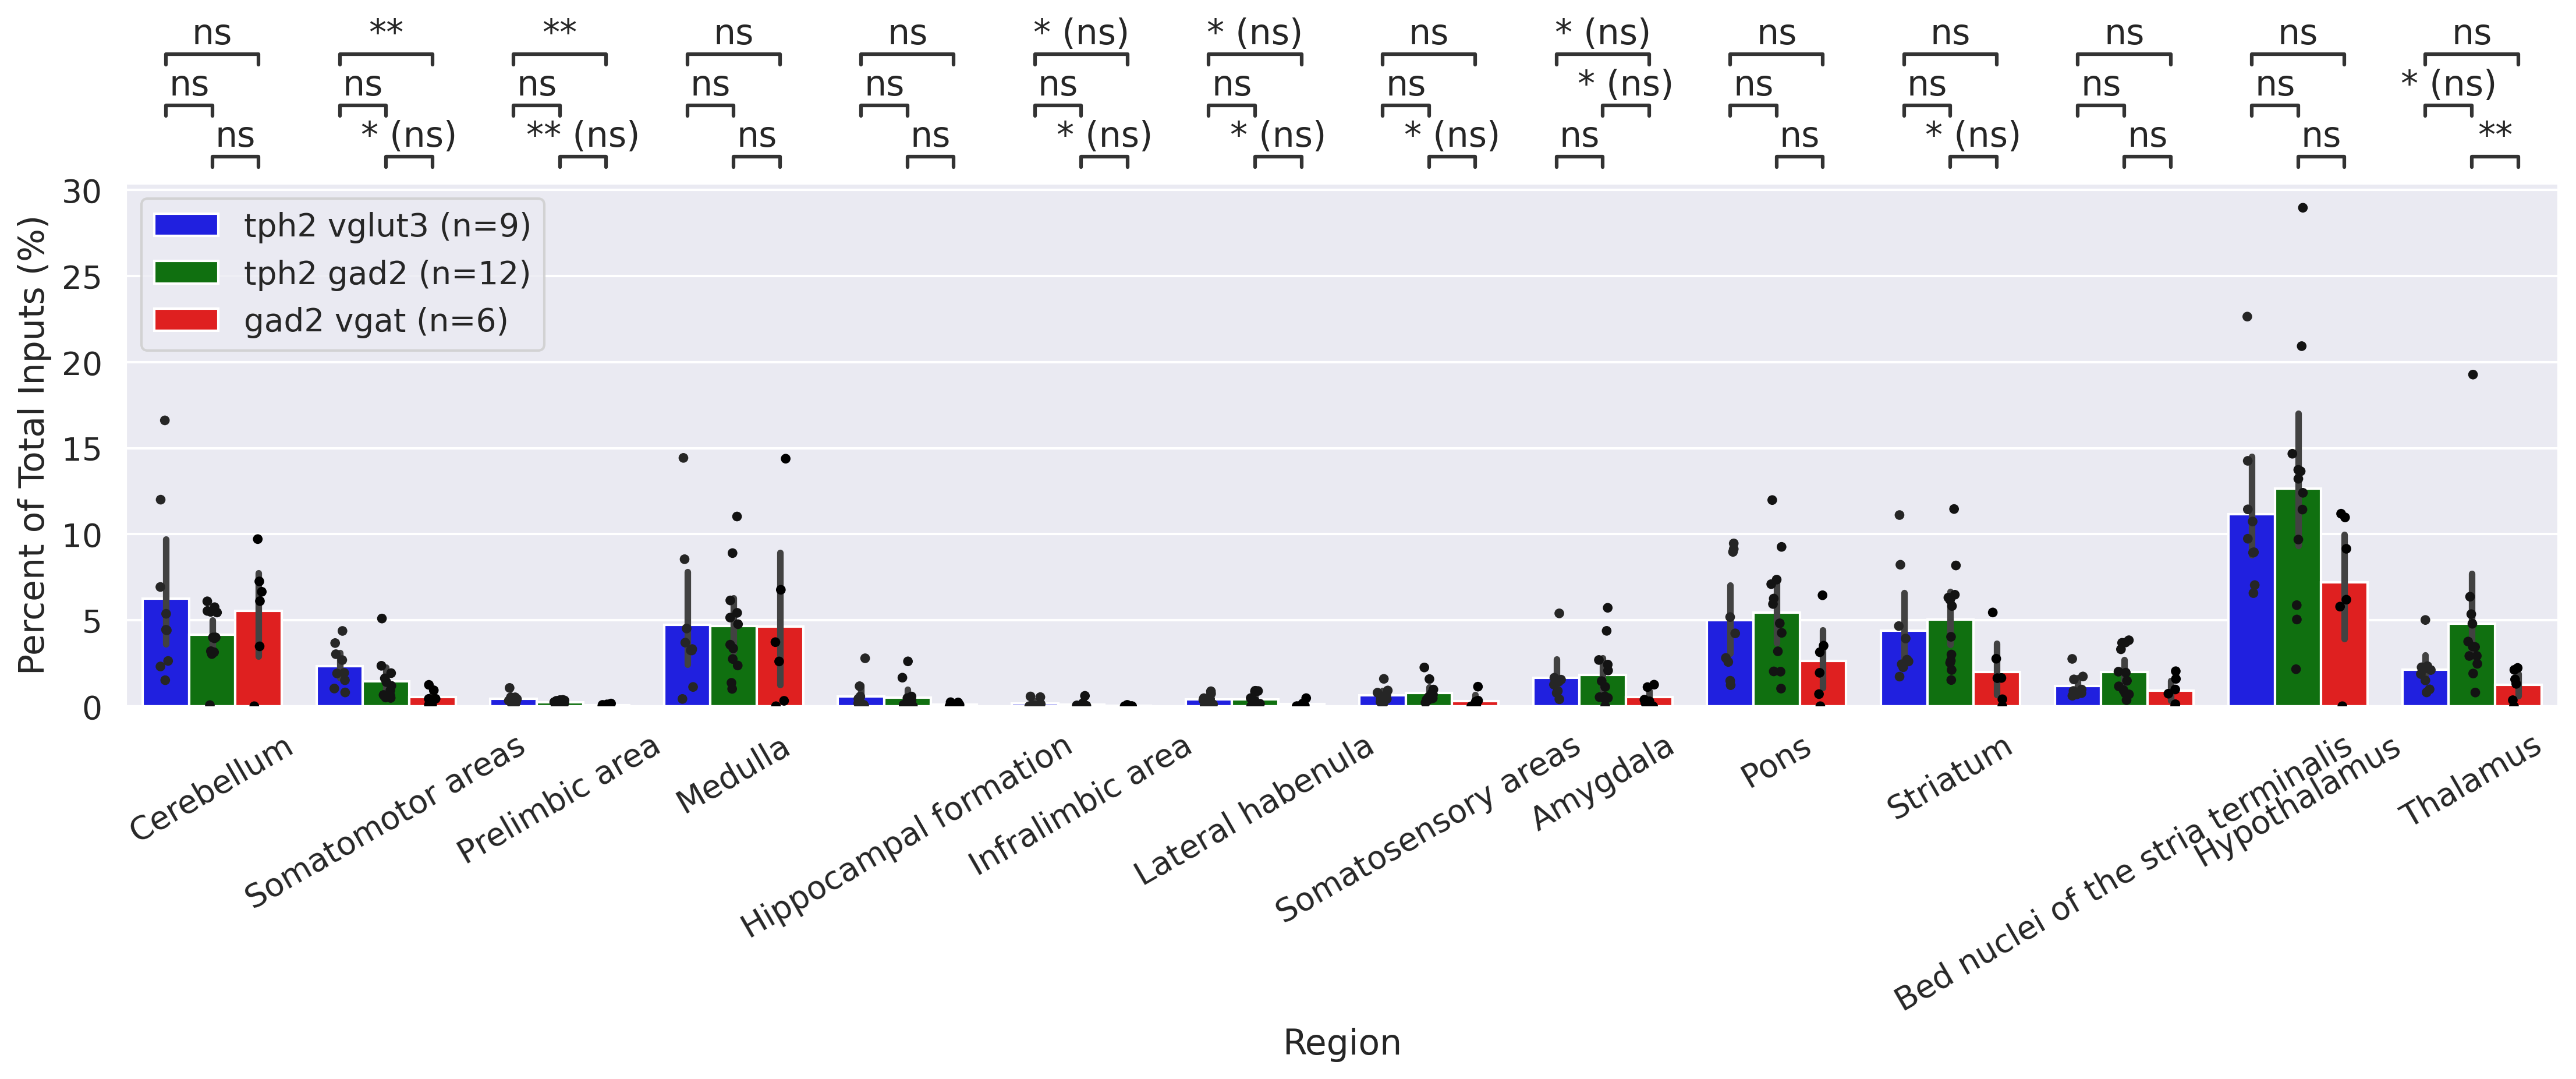

In [9]:
test = StatTest(
    _log_ttest_ind, test_long_name="Log t-test_ind", test_short_name="log-t"
)
test = "Mann-Whitney"
# test = "t-test_ind"
dep_var = "Percent of Total Inputs (%)"
pad = 0

region_names = []
pcts = []
counts = []
ids = []
subtypes = []
subtype_counts = {}

for brain_id in sd.brain_ids:
    subtype = sd.brain2paths[brain_id]["subtype"]
    if subtype in subtype_counts.keys():
        subtype_counts[subtype] = subtype_counts[subtype] + 1
    else:
        subtype_counts[subtype] = 1

    for region in regions:
        count = np.amax([pad, sd.region_graph.nodes[region][brain_id]])
        pct = count / sd.region_graph.nodes[997][brain_id] * 100
        if pct == 0:
            print(
                f"0 somas in region: {sd.region_graph.nodes[region]['name']} ({region}) for sample {brain_id} in group {subtype}"
            )
        pcts.append(pct)
        counts.append(sd.region_graph.nodes[region][brain_id])
        subtypes.append(subtype)
        ids.append(brain_id)
        region_names.append(sd.region_graph.nodes[region]["name"])
    for composite_region in composite_regions.keys():
        composite_region_regions = composite_regions[composite_region]
        total = 0
        for region in composite_region_regions:
            total += sd.region_graph.nodes[region][brain_id]
        pcts.append(total / sd.region_graph.nodes[997][brain_id] * 100)
        counts.append(total)
        subtypes.append(subtype)
        ids.append(brain_id)
        region_names.append(composite_region)

# append n to subtypes
color_palette = {}
for i, subtype in enumerate(subtypes):
    new_key = subtype + f" (n={subtype_counts[subtype]})"
    subtypes[i] = new_key 
    color_palette[new_key] = colors[subtype]


data = {
    "Region": region_names,
    "Brain ID": ids,
    "Subtype": subtypes,
    "Percent of Total Inputs (%)": pcts,
    "Total Somas": counts,
}
df = pd.DataFrame(data=data)


# bplot = sns.stripplot(x = "Total Somas", y = "Region", hue="Brain ID", data=df)
# bplot.set_xscale("log")
# plt.show()

diffs = []
for region_name in df["Region"].unique():
    diff = (
        df[
            (df["Region"] == region_name)
            & (df["Subtype"] == f"tph2 gad2 (n={subtype_counts['tph2 gad2']})")
        ][dep_var].mean()
        - df[
            (df["Region"] == region_name)
            & (df["Subtype"] == f"tph2 vglut3 (n={subtype_counts['tph2 vglut3']})")
        ][dep_var].mean()
    )
    diffs.append((region_name, diff))


def second(e):
    return e[1]


diffs.sort(key=second, reverse=False)
order = [e[0] for e in diffs]

sns.set(font_scale=1.2)
fig, ax = plt.subplots(1, 1, figsize=(15, 7), dpi=300)
fig_args = {
    "x": "Region",
    "y": dep_var,
    "hue": "Subtype",
    "data": df,
    "dodge": True,
    "order": order,
}
bplot = sns.stripplot(ax=ax, color='black', size=4, **fig_args)
#fig_args["boxprops"] = {"facecolor": "none"}
#bplot = sns.boxplot(ax=ax, **fig_args)
bplot = sns.barplot(ax=ax, palette=color_palette, **fig_args)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles[3:], labels=labels[3:])

#bplot.set_yscale("log")
xtick_labels = bplot.get_xticklabels()
# for i, x_lbl in enumerate(xtick_labels):
#     if x_lbl.get_text() == "Bed nuclei of the stria terminalis":
#         xtick_labels[i].set_text("BNST")
#         break
bplot.set_xticklabels(labels=xtick_labels, rotation=30)

# annotator
fig_args["x"] = "Region"
fig_args["y"] = dep_var
pairs = []
unq_subtypes = np.unique(subtypes)
for region in regions + ["Amygdala"]:
    if region == "Amygdala":
        region_name = region
    else:
        region_name = sd.region_graph.nodes[region]["name"]

    for i, subtype1 in enumerate(unq_subtypes):
        for subtype2 in unq_subtypes[i + 1 :]:
            pairs.append(((region_name, subtype1), (region_name, subtype2)))
annot = Annotator(ax, pairs, **fig_args)
annot.configure(
    test=test, text_format="star", loc="outside", comparisons_correction="BH",
)
fig_args["y"] = dep_var
fig_args["x"] = "Region"
annot.new_plot(bplot, orient="v", plot="barplot", **fig_args)
annot.apply_and_annotate()


# markers = ["o", "v", "^", "<", ">", "s", "p", "*", "+", "x", "D", "h", "H", "o", "o", "o", "o", "o", "o"]
# jitters = {"tph2 vglut3": -0.26, "tph2 gad2": 0, "gad2 vgat": 0.26}
# id2marker = {id: markers[idx] for idx, id in enumerate(brain_ids)}
# for idx, line in df.iterrows():
#     st = line["Subtype"].split("(")[0][:-1]

#     x = line["Percent of Total Inputs (%)"]
#     y = order.index(line["Region"]) + jitters[st]
#     c = colors[st]
#     marker = id2marker[line["Brain ID"]]
#     ax.scatter([x], [y], c=c, marker=marker)


fig.tight_layout()
